# Note on generating the correct number density of galaxies

`meer21cm` supports mock routines to generate galaxy catalogue for cross-correlation analysis. For generation of galaxies, an important input is the number density across the redshifts of interest. In this notebook, we briefly explain the implementation in `meer21cm`.

In [1]:
from meer21cm import MockSimulation
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from meer21cm.util import create_wcs, redshift_to_freq, radec_to_indx
from meer21cm.plot import plot_map


## Input source number

In `meer21cm`, there are two separate inputs: `MockSimulation.num_discrete_source`, and `MockSimulation.discrete_source_dndz`. Note that they **do not** need to be consistent with each other. The total number of sources generated only depends on the `num_discrete_source` input, and `discrete_source_dndz` is only used for its shape. `num_discrete_source` should be an integer, whereas `discrete_source_dndz` should be a callable function that takes redshift as an input. Let's first look at the source number:

In [2]:
z_min = 0.5
z_max = 1.5
nu_min = redshift_to_freq(z_max)
nu_max = redshift_to_freq(z_min)
nu = np.linspace(nu_min,nu_max,50)
num_pix_x = 100
num_pix_y = 100
ang_resol = 0.3
wcs = create_wcs(180,-30,[num_pix_x,num_pix_y],ang_resol)
mock = MockSimulation(
    seed=1,
    nu=nu,
    wproj=wcs,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
    tracer_bias_2=1.0,
)

Let's say you want 0.1 galaxy per arcmin^2. You can then set the total number of galaxies:

In [3]:
# pixel_area is sq deg
# W_HI at one channel gives you total number of pixels that are surveyed
tot_num_source = int(mock.pixel_area * 3600 * 0.1 * mock.W_HI[:,:,0].sum())
mock.num_discrete_source = tot_num_source

Run the simulation:

In [4]:
mock.propagate_mock_tracer_to_gal_cat();

Note that, the generated galaxy catalogue is generated at the rectangular box level, with a box that encloses the entire survey lightcone. This means that lots of generated galaxies actually are outside of the survey area:

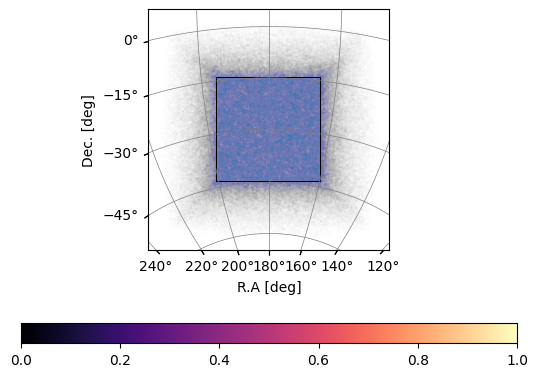

In [5]:
plot_map(mock.W_HI, mock.wproj)
ax = plt.gca()
ax.scatter(
    mock.ra_gal,
    mock.dec_gal,
    s=0.1,
    alpha=0.01,
    transform=ax.get_transform('world'),
)

And therefore, the total number of galaxies are larger than the specified `num_discrete_source`:

In [6]:
mock.z_gal.size, mock.num_discrete_source

(555989, 311169)

While it is often not needed, there are some functionalities for you to check the number density within the survey area:

In [7]:
indx_1, indx_2 = radec_to_indx(mock.ra_gal, mock.dec_gal, mock.wproj)
in_range = (indx_1 >= 0) * (indx_1 < mock.num_pix_x) * (indx_2 >= 0) * (indx_2 < mock.num_pix_y)
in_range.sum(), mock.num_discrete_source

(np.int64(322933), 311169)

As you can see, they agree with each other within Poisson errors.

Usually, in data analysis, you would specify a trimming range within which you do the power spectrum estimation. `meer21cm` takes that into account and adjusts the number of sources generated, so within the survey area you always have the input `num_discrete_source`. Furthermore, if `trim=True` (which is default) when you call `mock.propagate_mock_tracer_to_gal_cat()`, then the galaxy catalogue is trimmed as well to the range:

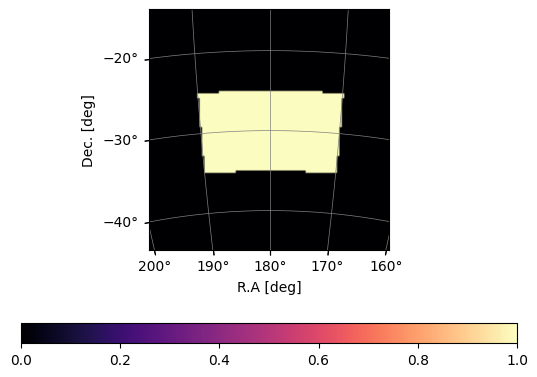

In [8]:
mock = MockSimulation(
    seed=1,
    nu=nu,
    wproj=wcs,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
    tracer_bias_2=1.0,
    ra_range=[170,190],
    dec_range=[-35,-25],
)
plot_map(mock.W_HI, mock.wproj)

In [9]:
tot_num_source = int(mock.pixel_area * 3600 * 0.1 * mock.W_HI[:,:,0].sum())
mock.num_discrete_source = tot_num_source
# note that the number of sources is smaller due to smaller survey area
tot_num_source

61981

In [10]:
mock.propagate_mock_tracer_to_gal_cat()

Now the galaxy catalogue is within the range:

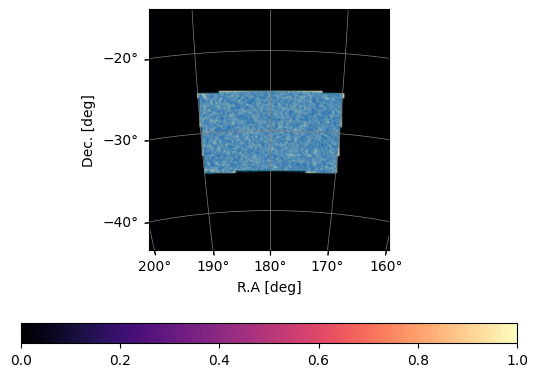

In [11]:
plot_map(mock.W_HI, mock.wproj)
ax = plt.gca()
ax.scatter(
    mock.ra_gal,
    mock.dec_gal,
    s=0.1,
    alpha=0.1,
    transform=ax.get_transform('world'),
)

If you want to use the full catalogue in the rectangular box, you can always just use `mock.ra_mock_tracer` (`dec_mock_tracer`, `z_mock_tracer`) and do your own trimming or any other manipulation:

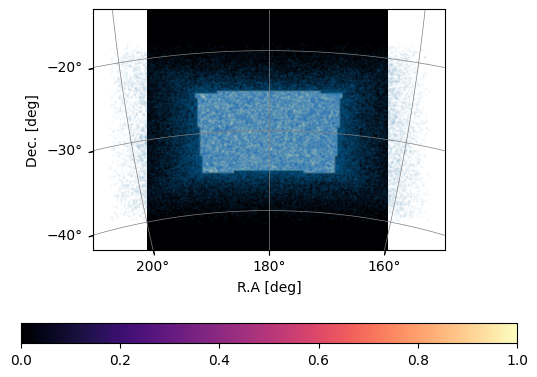

In [12]:
plot_map(mock.W_HI, mock.wproj)
ax = plt.gca()
ax.scatter(
    mock.ra_mock_tracer,
    mock.dec_mock_tracer,
    s=0.1,
    alpha=0.1,
    transform=ax.get_transform('world'),
)

## Input redshift distribution

Usually, the galaxy survey catalogue follows non-uniform redshift distribution. In `meer21cm`, you can generate these redshift kernels through the input `discrete_source_dndz`. 

**Important**: `discrete_source_dndz` uses comoving volume unit! That is to say, the `dndz` (or sometimes called `n(z)`) should be in the unit of $\rm Mpc^{-3}$ . Since the amplitude does not matter, the exact unit also does not matter. For example it can also be (h/Mpc)$^3$

The default is uniform distribution. However, if you plot the histogram of the source redshifts, it is not uniform:

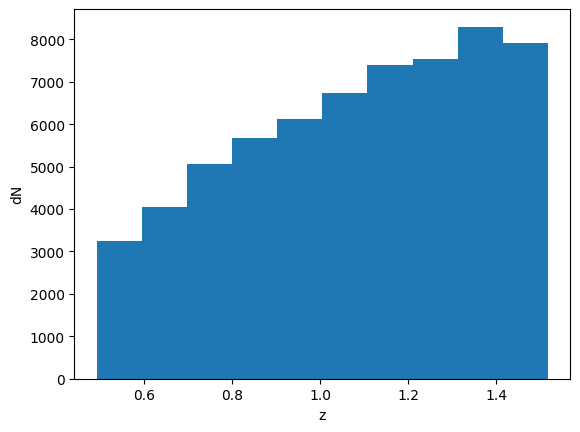

In [13]:
plt.hist(mock.z_gal);
plt.xlabel('z')
plt.ylabel('dN');

Again, note that you are plotting it in unitless (or in some sense per angular area) dimension. If you want to plot it in volume, you need to take the differential comoving volume:

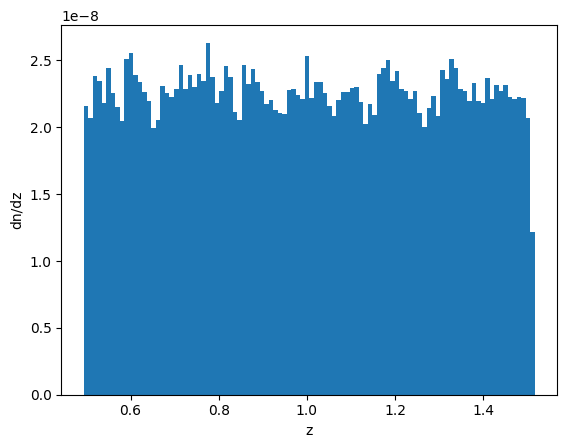

In [14]:
# for computational efficiency, first interpolate dV
z_arr = np.linspace(0, 2, 1000)
dV_arr = mock.cosmo.differential_comoving_volume(z_arr)
dV_func = interp1d(z_arr, dV_arr)

plt.hist(mock.z_gal, bins=100, weights=1 / dV_func(mock.z_gal));
plt.xlabel('z')
plt.ylabel('dn/dz');

You can see indeed the distribution is uniform.

Reversely, if you want an input redshift kernel without comoving volume unit, for example your `n(z)` is in per square degree, then you would need to modify your input:

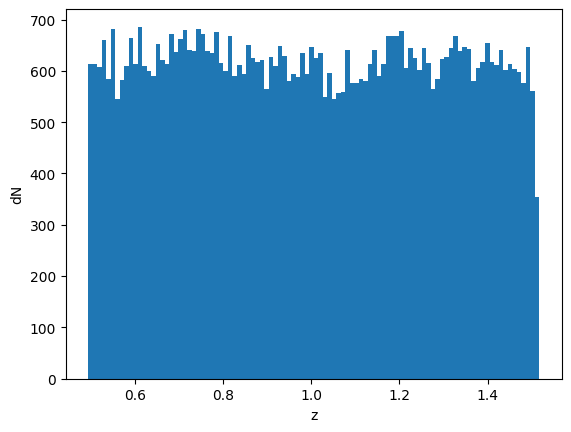

In [15]:
# transform the dndz to comoving volume unit
dndz_func = lambda z: np.ones_like(z) / dV_func(z)
mock.discrete_source_dndz = dndz_func
# rerun the simulation
mock.propagate_mock_tracer_to_gal_cat()

plt.hist(mock.z_gal, bins=100,);
plt.xlabel('z')
plt.ylabel('dN');

Now it's uniform in terms of number count instead of number density

In reality, you may want some form of kernel which you extract from an actual survey or realistic simulations. Suppose you have a `dn/dz` that you want:

In [16]:
# Gaussian kernel just for demonstration
dndz_func = lambda z: np.exp(-(z-1.0)**2 / 0.3**2)
mock.discrete_source_dndz = dndz_func
mock.propagate_mock_tracer_to_gal_cat();

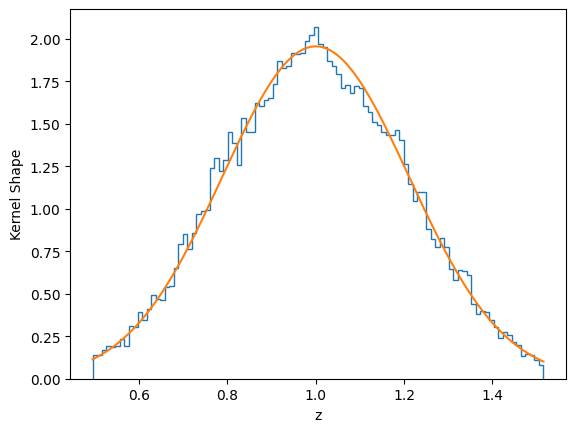

In [17]:
count,bins = np.histogram(mock.z_gal, bins=100, weights=1 / dV_func(mock.z_gal));
plt.stairs(count/count.mean(), bins);
z_plot_arr = np.linspace(mock.z_gal.min(), mock.z_gal.max(), 1000)
dndz_plot_arr = dndz_func(z_plot_arr)
plt.plot(z_plot_arr, dndz_plot_arr/dndz_plot_arr.mean());
plt.xlabel('z')
plt.ylabel('Kernel Shape');

As you can see, the simulation generates the correct dndz that matches your input